# Exploratory data analysis

Corpus statistics, tag distributions and graph properties for the three
datasets. Run the matching preprocessing stage first.

In [1]:
import json
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch

PROC = Path("../data/processed")
print([p.name for p in PROC.iterdir() if p.is_dir()])

['musiccaps', 'mtat', 'GTZAN']


## 1. Corpus sizes and segmentation

In [2]:
rows = []
for ds in ("gtzan", "mtat", "musiccaps"):
    d = PROC / ds
    if not (d / "train.parquet").exists():
        continue
    parts = {s: pd.read_parquet(d / f"{s}.parquet", columns=["track_id"])
             for s in ("train", "val", "test")}
    seg_per_clip = pd.concat(parts.values()).groupby("track_id").size()
    rows.append({
        "dataset": ds,
        "clips": sum(p.track_id.nunique() for p in parts.values()),
        "segments": sum(len(p) for p in parts.values()),
        "seg/clip": round(seg_per_clip.mean(), 2),
        "train": parts["train"].track_id.nunique(),
        "val": parts["val"].track_id.nunique(),
        "test": parts["test"].track_id.nunique(),
    })
pd.DataFrame(rows).set_index("dataset")

,clips,segments,seg/clip,train,val,test
dataset,,,,,,
gtzan,999,5985,5.99,699,150,150
mtat,17414,87070,5.00,12213,2563,2638
musiccaps,5299,26481,5.00,3709,794,796


## 2. Tag frequency distribution

Multi-label tagging is dominated by the long tail: a handful of tags carry most
of the positives, and the rarest tags near the frequency floor are where
Macro-F1 is won or lost.

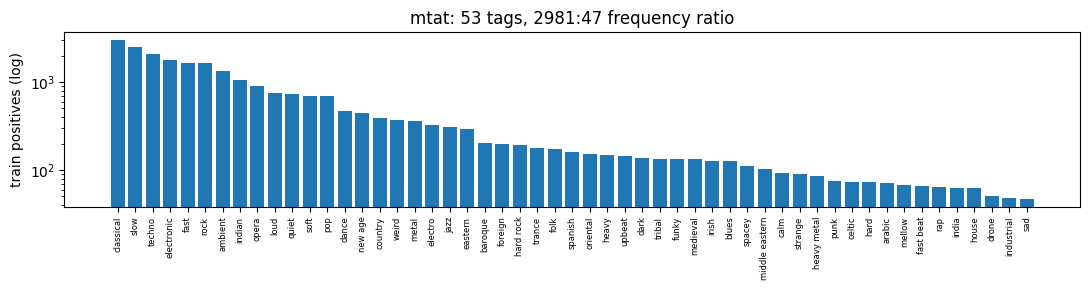

mtat: label density 3.90% -> random AUC-PR floor ~0.0390


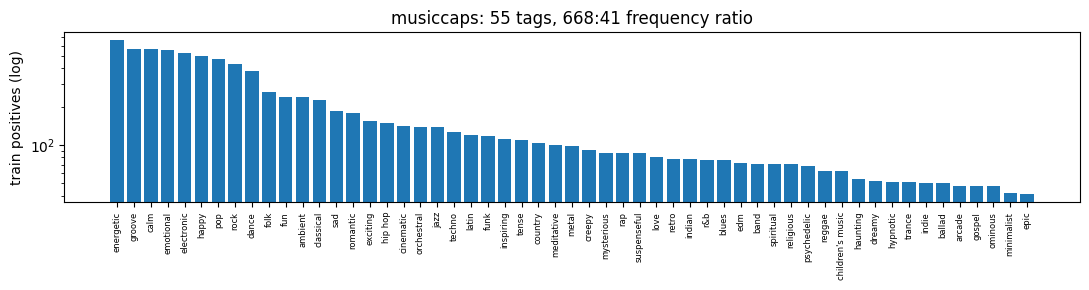

musiccaps: label density 4.59% -> random AUC-PR floor ~0.0459


In [3]:
import matplotlib.pyplot as plt

for ds in ("mtat", "musiccaps"):
    ls_path = PROC / ds / "label_space.json"
    if not ls_path.exists():
        continue
    ls = json.loads(ls_path.read_text())
    tags = ls.get("tags") or (ls["genre"] + ls["mood"])
    counts = np.array(ls["train_positives"])
    order = np.argsort(-counts)

    fig, ax = plt.subplots(figsize=(11, 3))
    ax.bar(range(len(counts)), counts[order])
    ax.set_yscale("log")
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels([tags[i] for i in order], rotation=90, fontsize=6)
    ax.set_ylabel("train positives (log)")
    ax.set_title(f"{ds}: {len(tags)} tags, "
                 f"{counts.max()}:{counts.min()} frequency ratio")
    plt.tight_layout(); plt.show()

    density = counts.sum() / (ls["n_train_clips"] * len(tags))
    print(f"{ds}: label density {density:.2%} -> random AUC-PR floor ~{density:.4f}")

## 3. Graph properties

In [5]:
import torch

def stats_from_graphs(path):
    """Recompute from a cached .pt when no stats JSON was written."""
    gs = torch.load(path, weights_only=False)
    n_sim = np.array([int((g.edge_attr[:, 0] < 0.5).sum()) // 2 for g in gs])
    n_seg = np.array([int(g.num_segments) for g in gs])
    y = torch.cat([g.y for g in gs])
    return {"segments_per_clip_mean": round(float(n_seg.mean()), 2),
            "similarity_edges_mean": round(float(n_sim.mean()), 2),
            "zero_edge_fraction": round(float((n_sim == 0).mean()), 4),
            "labels_per_clip_mean": round(float(y.sum(dim=1).mean().item()), 2)
                                    if y.dim() == 2 and y.shape[1] > 1 else None}

rows, notes = [], []
for ds in ("gtzan", "mtat", "musiccaps"):
    gdir = PROC / ds / "graphs"
    if not gdir.exists():
        notes.append(f"{ds}: no graphs/ directory")
        continue

    found = sorted(gdir.glob("graph_stats*.json"))
    if found:
        for f in found:
            s = json.loads(f.read_text())
            s = s.get("train", s)
            policy = f.stem.replace("graph_stats", "").lstrip("_") or "default"
            rows.append({"dataset": ds, "policy": policy, "source": "json",
                         "nodes": s.get("segments_per_clip_mean"),
                         "sim edges": s.get("similarity_edges_mean"),
                         "bare chain %": round(100 * s["zero_edge_fraction"], 1)
                                         if "zero_edge_fraction" in s else None,
                         "labels/clip": s.get("labels_per_clip_mean")})
    else:
        pts = sorted(gdir.glob("train_*.pt"))
        if not pts:
            notes.append(f"{ds}: {gdir} exists but holds "
                         f"{[p.name for p in gdir.iterdir()][:4]}")
        for pt in pts:
            s = stats_from_graphs(pt)
            rows.append({"dataset": ds, "policy": pt.stem, "source": "recomputed",
                         "nodes": s["segments_per_clip_mean"],
                         "sim edges": s["similarity_edges_mean"],
                         "bare chain %": round(100 * s["zero_edge_fraction"], 1),
                         "labels/clip": s["labels_per_clip_mean"]})

for n in notes:
    print(n)
pd.DataFrame(rows) if rows else print("nothing found -- run graph_builder.py first")

,dataset,policy,source,nodes,sim edges,bare chain %,labels/clip
0,gtzan,tau,json,NaN,1.84,NaN,NaN
1,mtat,default,json,5.0,2.00,0.0,2.07
2,mtat,tau,json,5.0,0.97,35.0,2.07
3,musiccaps,tau,json,5.0,0.87,40.7,2.52
4,musiccaps,topk,json,5.0,2.00,0.0,2.52


### Why the bare-chain rate differs between corpora

Track-centring forces the segment vectors to sum to zero, so the mean pairwise
cosine is pinned at $-1/(n-1)$ regardless of the audio. With fewer segments
there are fewer candidate pairs, so more clips come up empty at the same
acceptance rate — it is arithmetic, not a threshold failure.

In [6]:
from math import comb
for name, n, edges in [("GTZAN", 6, 1.84), ("MTAT", 5, 0.97)]:
    pairs = comb(n, 2) - (n - 1)
    hit = edges / pairs
    print(f"{name}: {n} segments, {pairs} non-adjacent pairs, "
          f"acceptance {hit:.1%} -> predicted zero-edge {(1-hit)**pairs:.1%}")

GTZAN: 6 segments, 10 non-adjacent pairs, acceptance 18.4% -> predicted zero-edge 13.1%
MTAT: 5 segments, 6 non-adjacent pairs, acceptance 16.2% -> predicted zero-edge 34.7%


## 4. Caption uniqueness (decides whether Task 4 retrieval is meaningful)

In [7]:
for ds in ("mtat", "musiccaps"):
    f = PROC / ds / "test.parquet"
    if not f.exists():
        continue
    texts = pd.read_parquet(f, columns=["track_id", "text"]).drop_duplicates("track_id").text
    c = Counter(texts)
    print(f"{ds}: {len(texts)} clips, {len(c)} unique captions "
          f"({len(c)/len(texts):.1%}), largest group {max(c.values())}")
    print(f"   example: {texts.iloc[0][:110]}")

mtat: 2638 clips, 1180 unique captions (44.7%), largest group 456
   example: A music clip featuring violin.
musiccaps: 796 clips, 796 unique captions (100.0%), largest group 1
   example: This song features a rubber instrument being played. The strumming is fast. The melody is played on one frette
